In [ ]:
import pandas as pd
df = pd.read_parquet("/kaggle/input/datasets/kylenaluan/ecommerce-data-from-oct-and-nov-cleaned/ecommerce_oct_nov_clean.parquet")

# Visualizing Customer Behavior

In [2]:
import pandas as pd

#Create indicators
df['view'] = (df['event_type'] == 'view').astype(int)
df['cart'] = (df['event_type'] == 'cart').astype(int)
df['purchase'] = (df['event_type'] == 'purchase').astype(int)

# Aggregate
actions = df.groupby(['user_id', 'category_code']).agg({
    'view': 'sum',
    'cart': 'sum',
    'purchase': 'sum'
}).reset_index()

In [3]:
actions['viewed'] = actions['view'] > 0
actions['added_to_cart'] = actions['cart'] > 0
actions['purchased'] = actions['purchase'] > 0

In [4]:
total_viewed = actions['viewed'].sum()
total_viewed

np.int64(12407928)

In [5]:
added_to_cart = actions['added_to_cart'].sum()
ignored = total_viewed - added_to_cart
ignored

np.int64(10998225)

In [6]:
cart_df = actions[actions['added_to_cart']]

purchased = cart_df['purchased'].sum()
not_purchased = len(cart_df) - purchased

In [7]:
cart_rate = added_to_cart / total_viewed
purchase_given_cart = purchased / added_to_cart

# Customer Journey Visualization

In [8]:
import plotly.express as px
import pandas as pd

data = pd.DataFrame({
    "stage": ["Viewed", "Viewed", "Added to Cart", "Added to Cart"],
    "next_stage": ["Ignored", "Added to Cart", "Purchased", "Not Purchased"],
    "count": [ignored, added_to_cart, purchased, not_purchased]
})

print(f"Viewed: {total_viewed}")

print(f"├── Ignored: {ignored} ({ignored/total_viewed:.2%})")

print(f"└── Added to Cart: {added_to_cart} ({cart_rate:.2%})")
print(f"    ├── Purchased: {purchased} ({purchase_given_cart:.2%})")
print(f"    └── Not Purchased: {not_purchased} ({not_purchased/added_to_cart:.2%})")

Viewed: 12407928
├── Ignored: 10998225 (88.64%)
└── Added to Cart: 1409703 (11.36%)
    ├── Purchased: 682334 (48.40%)
    └── Not Purchased: 727369 (51.60%)


In [9]:
import plotly.express as px
import pandas as pd

data = pd.DataFrame({
    "stage": ["Viewed", "Viewed", "Viewed"],
    "next_stage": ["Ignored", "Added to Cart", "Added to Cart"],
    "third_stage": ["Ignored","Purchased","Not Purchased"],
    "count": [ignored, purchased, not_purchased]
})
fig = px.sunburst(
    data,
    path=["stage", "next_stage","third_stage"],
    values="count",
    title="Customer Journey Flow"
)
fig.update_traces(
    textinfo="label+percent root"
)
fig.show()

All Events Visualized by User and Product

In [10]:
counts = (
    df.groupby(['user_id', 'product_id','event_type'])
      .size()
      .unstack(fill_value=0)
)

counts

event_type            cart  purchase  view
user_id   product_id                      
10300217  26300219       0         0     1
29515875  1801638        0         0     3
          1802034        0         0     2
          13200026       0         0     1
          13200917       0         0     4
...                    ...       ...   ...
579969605 30200000       0         0     1
579969658 21403472       0         0     1
579969711 2600400        0         0     3
579969767 4804718        0         0     1
579969851 1004233        0         0     1

[56371590 rows x 3 columns]

# Abandoned Cart Analysis

Find patterns with which products are not purchased after being added to cart.

First, we looked at the category of the products. 

Second, we looked at the time of day of the original cart. 

Then, we looked at the number of hours since the original cart.

Finally, we looked at the price of the item.

# Category

In [11]:
cart_df

,user_id,category_code,view,cart,purchase,viewed,added_to_cart,purchased
20,74383042,computers.components.cooler,6,1,0,True,True,False
32,94566147,electronics.smartphone,21,1,0,True,True,False
48,107837897,auto.accessories.videoregister,27,4,0,True,True,False
67,121339215,unknown,7,1,0,True,True,False
72,124298297,unknown,7,2,0,True,True,False
...,...,...,...,...,...,...,...,...
12409309,579965069,electronics.smartphone,4,1,0,True,True,False
12409333,579966375,electronics.smartphone,2,1,1,True,True,True
12409343,579967058,electronics.smartphone,3,1,1,True,True,True
12409348,579967455,electronics.smartphone,1,1,0,True,True,False


In [12]:
category_analysis = (
    cart_df.groupby('category_code')
    .agg(
        total_carts=('cart', 'sum'),          # total add-to-cart events
        total_rows=('purchased', 'count'),    # number of user-product cases
        purchased=('purchased', 'sum')        # number of True purchases
    )
)

In [13]:
category_analysis['not_purchased'] = category_analysis['total_rows'] - category_analysis['purchased']
category_analysis['not_purchased_pct'] = category_analysis['not_purchased'] / category_analysis['total_carts']

In [14]:
category_analysis = category_analysis[category_analysis['total_rows'] > 5]

category_analysis = category_analysis.sort_values(by='not_purchased_pct')
category_analysis

,total_carts,total_rows,purchased,not_purchased,not_purchased_pct
category_code,,,,,
electronics.smartphone,1651398,507588,279539,228049,0.138095
unknown,903247,333374,151487,181887,0.201370
electronics.audio.headphone,178351,69983,33944,36039,0.202068
appliances.kitchen.washer,87513,35367,16574,18793,0.214745
appliances.environment.air_heater,15651,6584,3174,3410,0.217877
...,...,...,...,...,...
construction.tools.soldering,39,30,6,24,0.615385
apparel.skirt,60,46,8,38,0.633333
apparel.shoes.slipons,47,34,3,31,0.659574


In [15]:
category_analysis.sort_values(by='purchased', ascending=False).head()

,total_carts,total_rows,purchased,not_purchased,not_purchased_pct
category_code,,,,,
electronics.smartphone,1651398,507588,279539,228049,0.138095
unknown,903247,333374,151487,181887,0.201370
electronics.audio.headphone,178351,69983,33944,36039,0.202068
electronics.video.tv,137445,57226,26676,30550,0.222271
electronics.clocks,87880,37962,17711,20251,0.230439


 # Time of Day

In [16]:
time_df = df
time_df['event_time'] = pd.to_datetime(time_df['event_time'])
time_df['hour'] = time_df['event_time'].dt.hour
time_df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,view,cart,purchase,hour
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,unknown,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,1,0,0,0
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,1,0,0,0
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,1,0,0,0
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,0,0,0
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109819999,2019-11-30 23:59:58+00:00,view,15700137,2053013559733912211,unknown,unknown,277.739990,532714000,02b4131c-0112-4231-aafa-ceaa08e77c1b,1,0,0,23
109820000,2019-11-30 23:59:58+00:00,view,28719425,2053013565639492569,apparel.shoes,baden,62.810001,545223467,734c5eef-0742-4f8b-9d22-48f75b0bc359,1,0,0,23
109820001,2019-11-30 23:59:59+00:00,view,1004833,2053013555631882655,electronics.smartphone,samsung,167.029999,557794415,6fecf566-ebb0-4e70-a243-cdc13ce044cb,1,0,0,23
109820002,2019-11-30 23:59:59+00:00,view,2701706,2053013563911439225,appliances.kitchen.refrigerators,samsung,566.270020,531607492,368ddc8b-5db9-40fb-b7ff-b6582a1192c0,1,0,0,23


In [17]:
cart_time_df = (
    time_df[time_df['event_type'] == 'cart']
    .groupby(['user_id', 'product_id','hour'])
    .size()
    .reset_index(name='cart')
)

cart_time_df['cart'] = 1
cart_time_df

,user_id,product_id,hour,cart
0,74383042,30901102,10,1
1,94566147,1005007,8,1
2,107837897,4700199,8,1
3,107837897,4700419,8,1
4,107837897,4700419,15,1
...,...,...,...,...
2545882,579965069,1005105,23,1
2545883,579966375,1004856,23,1
2545884,579967058,1004856,23,1
2545885,579967455,1004767,23,1


In [18]:
purchase_time_df = (
    time_df[time_df['event_type'] == 'purchase']
    .groupby(['user_id', 'product_id'])
    .size()
    .reset_index(name='purchased')
)
purchase_time_df['purchased'] = 1
purchase_time_df

,user_id,product_id,purchased
0,138340325,17301041,1
1,225644257,6800309,1
2,253299396,2400724,1
3,256164170,3900975,1
4,264649825,8500083,1
...,...,...,...
1256873,579962677,1005135,1
1256874,579963523,1002544,1
1256875,579964521,100012279,1
1256876,579966375,1004856,1


In [19]:
in_cart_time_df = cart_time_df.merge(
    purchase_time_df,
    on=['user_id', 'product_id'],
    how='left'
)
in_cart_time_df['purchased'] = in_cart_time_df['purchased'].fillna(0)
in_cart_time_df = in_cart_time_df.rename(columns={'hour': 'hour_added_to_cart'})
in_cart_time_df

,user_id,product_id,hour_added_to_cart,cart,purchased
0,74383042,30901102,10,1,0.0
1,94566147,1005007,8,1,0.0
2,107837897,4700199,8,1,0.0
3,107837897,4700419,8,1,0.0
4,107837897,4700419,15,1,0.0
...,...,...,...,...,...
2545882,579965069,1005105,23,1,0.0
2545883,579966375,1004856,23,1,1.0
2545884,579967058,1004856,23,1,1.0
2545885,579967455,1004767,23,1,0.0


In [20]:
hourly_purchase_rate = (
    in_cart_time_df.groupby('hour_added_to_cart')['purchased'].mean()
    .reset_index(name='purchase_rate')
)

hourly_purchase_rate

,hour_added_to_cart,purchase_rate
0,0,0.315624
1,1,0.283841
2,2,0.325777
3,3,0.407889
4,4,0.454815
5,5,0.466541
6,6,0.472173
7,7,0.470373
8,8,0.489961
9,9,0.518426


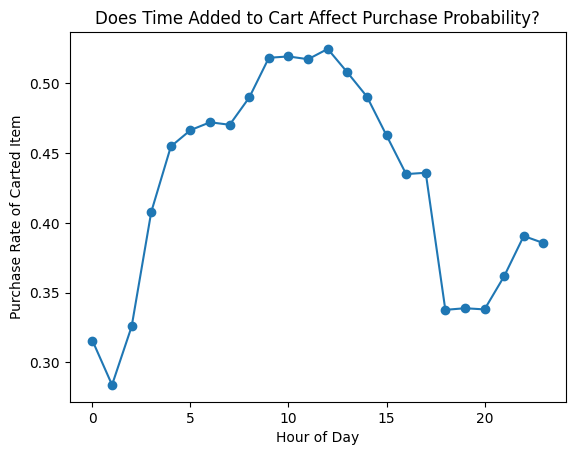

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(hourly_purchase_rate['hour_added_to_cart'], hourly_purchase_rate['purchase_rate'], marker='o')

plt.xlabel('Hour of Day')
plt.ylabel('Purchase Rate of Carted Item')
plt.title('Does Time Added to Cart Affect Purchase Probability?')

plt.show()

# Price

In [22]:
cart_price_df = (
    df[df['event_type'] == 'cart']
    .groupby(['user_id', 'product_id','price'])
    .size()
    .reset_index(name='cart')
)

cart_price_df['cart'] = 1
cart_price_df

,user_id,product_id,price,cart
0,74383042,30901102,81.519997,1
1,94566147,1005007,93.779999,1
2,107837897,4700199,179.899994,1
3,107837897,4700419,141.820007,1
4,107837897,4700557,137.199997,1
...,...,...,...,...
2305126,579965069,1005105,1302.479980,1
2305127,579966375,1004856,124.110001,1
2305128,579967058,1004856,124.110001,1
2305129,579967455,1004767,235.600006,1


In [23]:
purchase_price_df = (
    df[df['event_type'] == 'purchase']
    .groupby(['user_id', 'product_id'])
    .size()
    .reset_index(name='purchased')
)
purchase_time_df['purchased'] = 1
purchase_time_df

,user_id,product_id,purchased
0,138340325,17301041,1
1,225644257,6800309,1
2,253299396,2400724,1
3,256164170,3900975,1
4,264649825,8500083,1
...,...,...,...
1256873,579962677,1005135,1
1256874,579963523,1002544,1
1256875,579964521,100012279,1
1256876,579966375,1004856,1


In [24]:
in_cart_price_df = cart_price_df.merge(
    purchase_price_df,
    on=['user_id', 'product_id'],
    how='left'
)
in_cart_price_df['purchased'] = in_cart_price_df['purchased'].fillna(0)

in_cart_price_df

,user_id,product_id,price,cart,purchased
0,74383042,30901102,81.519997,1,0.0
1,94566147,1005007,93.779999,1,0.0
2,107837897,4700199,179.899994,1,0.0
3,107837897,4700419,141.820007,1,0.0
4,107837897,4700557,137.199997,1,0.0
...,...,...,...,...,...
2305126,579965069,1005105,1302.479980,1,0.0
2305127,579966375,1004856,124.110001,1,1.0
2305128,579967058,1004856,124.110001,1,1.0
2305129,579967455,1004767,235.600006,1,0.0


In [25]:
import numpy as np

bins = [0, 10, 30, 100, 500, in_cart_price_df['price'].max()+1]  
labels = ['<$10', '$10-$30', '30-100', '$100-$500', '$500+']

in_cart_price_df['price_bin'] = pd.cut(in_cart_price_df['price'], bins=bins, labels=labels)

in_cart_price_df

,user_id,product_id,price,cart,purchased,price_bin
0,74383042,30901102,81.519997,1,0.0,30-100
1,94566147,1005007,93.779999,1,0.0,30-100
2,107837897,4700199,179.899994,1,0.0,$100-$500
3,107837897,4700419,141.820007,1,0.0,$100-$500
4,107837897,4700557,137.199997,1,0.0,$100-$500
...,...,...,...,...,...,...
2305126,579965069,1005105,1302.479980,1,0.0,$500+
2305127,579966375,1004856,124.110001,1,1.0,$100-$500
2305128,579967058,1004856,124.110001,1,1.0,$100-$500
2305129,579967455,1004767,235.600006,1,0.0,$100-$500


In [26]:
price_summary = (
    in_cart_price_df.groupby('price_bin')['purchased'].mean()
    .reset_index(name='purchase_rate')
)

price_summary

/tmp/ipykernel_16/3182644360.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,price_bin,purchase_rate
0,<$10,0.324039
1,$10-$30,0.519488
2,30-100,0.502150
3,$100-$500,0.989236
4,$500+,1.142608


purchase_rate is greater than 1 for $500+ items. It is finding the average number of purchased items for each bin rather than the purchase rate. We will see an expensive item is bought multiple times. We will find the true purchase rate in future steps.

In [27]:
in_cart_price_df[in_cart_price_df['price_bin'] == '$500+'] \
    .sort_values(by='purchased', ascending=False)

,user_id,product_id,price,cart,purchased,price_bin
633675,518514099,1005116,1013.890015,1,140.0,$500+
633676,518514099,1005116,1013.929993,1,140.0,$500+
633668,518514099,1005116,1011.609985,1,140.0,$500+
633669,518514099,1005116,1013.280029,1,140.0,$500+
633671,518514099,1005116,1013.640015,1,140.0,$500+
...,...,...,...,...,...,...
161,350216377,1003965,589.440002,1,0.0,$500+
163,351362951,3600835,656.359985,1,0.0,$500+
172,354569623,17200020,514.559998,1,0.0,$500+
179,362327778,1004247,810.520020,1,0.0,$500+


In [28]:
in_cart_price_df['purchased_flag'] = (in_cart_price_df['purchased'] > 0).astype(int)

In [29]:
price_summary = (
    in_cart_price_df.groupby('price_bin')['purchased_flag']
    .mean()
    .reset_index(name='purchase_rate')
)
price_summary

/tmp/ipykernel_16/487556518.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,price_bin,purchase_rate
0,<$10,0.274791
1,$10-$30,0.366775
2,30-100,0.377082
3,$100-$500,0.482243
4,$500+,0.480487


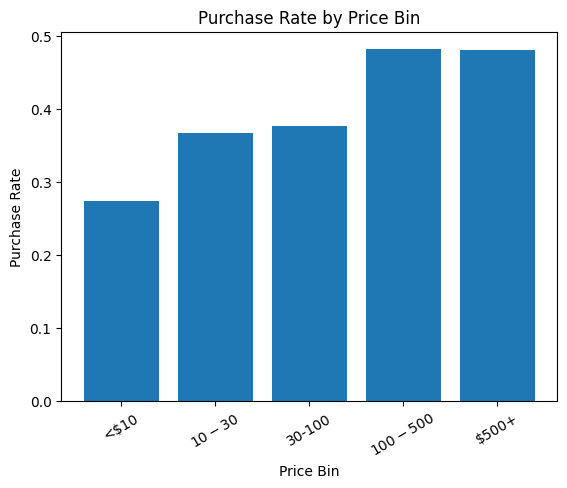

In [30]:
plt.figure()

plt.bar(price_summary['price_bin'], price_summary['purchase_rate'])

plt.title("Purchase Rate by Price Bin")
plt.xlabel("Price Bin")
plt.ylabel("Purchase Rate")

plt.xticks(rotation=30)  # rotate labels for readability

plt.show()

# Hours Since Item was Added to Cart
How long in advance are buyers adding their products to cart?

In [31]:
time_df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,view,cart,purchase,hour
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,unknown,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,1,0,0,0
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,1,0,0,0
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,1,0,0,0
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,0,0,0
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109819999,2019-11-30 23:59:58+00:00,view,15700137,2053013559733912211,unknown,unknown,277.739990,532714000,02b4131c-0112-4231-aafa-ceaa08e77c1b,1,0,0,23
109820000,2019-11-30 23:59:58+00:00,view,28719425,2053013565639492569,apparel.shoes,baden,62.810001,545223467,734c5eef-0742-4f8b-9d22-48f75b0bc359,1,0,0,23
109820001,2019-11-30 23:59:59+00:00,view,1004833,2053013555631882655,electronics.smartphone,samsung,167.029999,557794415,6fecf566-ebb0-4e70-a243-cdc13ce044cb,1,0,0,23
109820002,2019-11-30 23:59:59+00:00,view,2701706,2053013563911439225,appliances.kitchen.refrigerators,samsung,566.270020,531607492,368ddc8b-5db9-40fb-b7ff-b6582a1192c0,1,0,0,23


In [32]:
user_first_cart_df=time_df[time_df['event_type'] == 'cart'].copy()
user_first_buy_df=time_df[time_df['event_type']=='purchase'].copy()

user_first_cart_df= (
    user_first_cart_df.groupby(['user_id', 'product_id'])['event_time']
    .min()
    .reset_index(name='cart_time')
)

user_first_buy_df= (
    user_first_buy_df.groupby(['user_id', 'product_id'])['event_time']
    .min()
    .reset_index(name='buy_time')
)

user_first_buy_df

,user_id,product_id,buy_time
0,138340325,17301041,2019-11-11 05:47:14+00:00
1,225644257,6800309,2019-11-12 04:19:31+00:00
2,253299396,2400724,2019-11-06 10:53:31+00:00
3,256164170,3900975,2019-11-20 08:21:14+00:00
4,264649825,8500083,2019-10-06 15:29:00+00:00
...,...,...,...
1256873,579962677,1005135,2019-11-30 23:36:38+00:00
1256874,579963523,1002544,2019-11-30 23:41:03+00:00
1256875,579964521,100012279,2019-11-30 23:43:40+00:00
1256876,579966375,1004856,2019-11-30 23:49:23+00:00


In [33]:
cart_times = user_first_cart_df.merge(
    user_first_buy_df,
    on=['user_id', 'product_id'],
    how='left'
)
cart_times = cart_times.dropna(subset=['buy_time'])

cart_times['time_to_purchase']=cart_times['buy_time'] - cart_times['cart_time']

cart_times['hours_to_purchase'] = cart_times['time_to_purchase'].dt.total_seconds() / 3600

cart_times

,user_id,product_id,cart_time,buy_time,time_to_purchase,hours_to_purchase
24,225644257,6800309,2019-11-08 09:34:29+00:00,2019-11-12 04:19:31+00:00,3 days 18:45:02,90.750556
35,256164170,3900975,2019-11-20 08:16:19+00:00,2019-11-20 08:21:14+00:00,0 days 00:04:55,0.081944
47,267316896,26400963,2019-11-14 07:20:41+00:00,2019-11-14 07:22:44+00:00,0 days 00:02:03,0.034167
58,282274853,12700440,2019-11-08 08:46:55+00:00,2019-11-08 08:54:11+00:00,0 days 00:07:16,0.121111
77,296197073,4700553,2019-11-30 08:48:49+00:00,2019-11-30 08:50:49+00:00,0 days 00:02:00,0.033333
...,...,...,...,...,...,...
2092955,579962677,1005135,2019-11-30 23:35:08+00:00,2019-11-30 23:36:38+00:00,0 days 00:01:30,0.025000
2092957,579963523,1002544,2019-11-30 23:38:51+00:00,2019-11-30 23:41:03+00:00,0 days 00:02:12,0.036667
2092960,579964521,100012279,2019-11-30 23:42:40+00:00,2019-11-30 23:43:40+00:00,0 days 00:01:00,0.016667
2092962,579966375,1004856,2019-11-30 23:47:51+00:00,2019-11-30 23:49:23+00:00,0 days 00:01:32,0.025556


In [34]:
import numpy as np

bins = [0, 0.25, 2, 12, cart_times['hours_to_purchase'].max()+1]  # adjust as needed
labels = ['<15m', '15m-2h', '2-12h', '12h+']

cart_times['time_bin'] = pd.cut(cart_times['hours_to_purchase'], bins=bins, labels=labels)

cart_times

,user_id,product_id,cart_time,buy_time,time_to_purchase,hours_to_purchase,time_bin
24,225644257,6800309,2019-11-08 09:34:29+00:00,2019-11-12 04:19:31+00:00,3 days 18:45:02,90.750556,12h+
35,256164170,3900975,2019-11-20 08:16:19+00:00,2019-11-20 08:21:14+00:00,0 days 00:04:55,0.081944,<15m
47,267316896,26400963,2019-11-14 07:20:41+00:00,2019-11-14 07:22:44+00:00,0 days 00:02:03,0.034167,<15m
58,282274853,12700440,2019-11-08 08:46:55+00:00,2019-11-08 08:54:11+00:00,0 days 00:07:16,0.121111,<15m
77,296197073,4700553,2019-11-30 08:48:49+00:00,2019-11-30 08:50:49+00:00,0 days 00:02:00,0.033333,<15m
...,...,...,...,...,...,...,...
2092955,579962677,1005135,2019-11-30 23:35:08+00:00,2019-11-30 23:36:38+00:00,0 days 00:01:30,0.025000,<15m
2092957,579963523,1002544,2019-11-30 23:38:51+00:00,2019-11-30 23:41:03+00:00,0 days 00:02:12,0.036667,<15m
2092960,579964521,100012279,2019-11-30 23:42:40+00:00,2019-11-30 23:43:40+00:00,0 days 00:01:00,0.016667,<15m
2092962,579966375,1004856,2019-11-30 23:47:51+00:00,2019-11-30 23:49:23+00:00,0 days 00:01:32,0.025556,<15m


In [35]:
binned_cart_times = (
    cart_times.groupby('time_bin')
    .size()
    .reset_index(name='count')
)

/tmp/ipykernel_16/3770104636.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



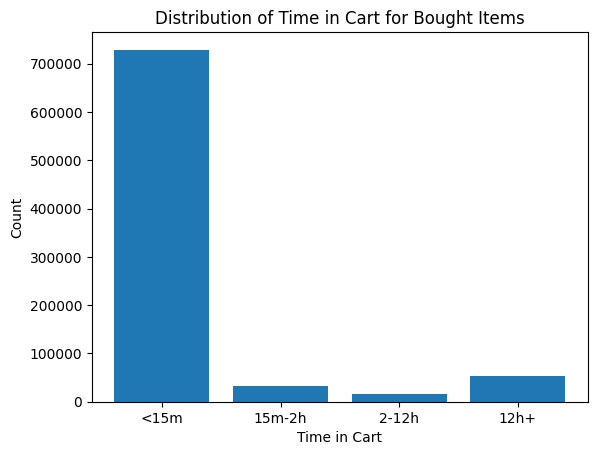

In [36]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(binned_cart_times['time_bin'].astype(str), binned_cart_times['count'])

plt.xlabel('Time in Cart')
plt.ylabel('Count')
plt.title('Distribution of Time in Cart for Bought Items')

plt.show()

This graph would indicate most items are bought within 15 minutes of being added to cart. It is not a stretch to assume most items are carted and bought in the same session. We look at patterns within the sessions where the cart is abandoned in Part B.

In [37]:
print(binned_cart_times[binned_cart_times['time_bin']=='<15m'])
print(binned_cart_times[binned_cart_times['time_bin']=='15m-2h'])
print(binned_cart_times[binned_cart_times['time_bin']=='2-12h'])
print(binned_cart_times[binned_cart_times['time_bin']=='12h+'])

  time_bin   count
0     <15m  729089
  time_bin  count
1   15m-2h  32402
  time_bin  count
2    2-12h  15769
  time_bin  count
3     12h+  53462
